<a href="https://colab.research.google.com/github/asheta66/Machine-Learning-2024/blob/main/OSA/OSA_Using_Evolutionary_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

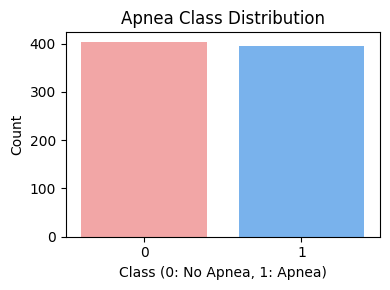

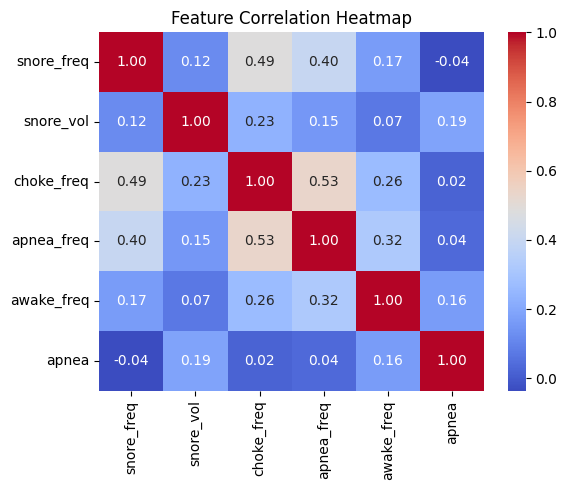

In [22]:
# ==========================================================
# 1. IMPORT LIBRARIES
# ==========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score
)

np.random.seed(42)

# Create folder for figures
import os
os.makedirs("figures", exist_ok=True)

# ==========================================================
# 2. USER-TUNABLE PARAMETERS
# ==========================================================
N_HIDDEN = 30
POP_SIZE = 30
ITERATIONS = 150

# GA parameters
CROSS_RATE = 0.85
MUT_RATE = 0.001

# PSO parameters
W = 0.5
C1 = 1.5
C2 = 1.5

# ==========================================================
# 3. LOAD & PREPROCESS DATA
# ==========================================================
df = pd.read_csv("sleep_disordered_breathing.csv")

X = df.drop(columns=["apnea"]).values
y = df["apnea"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.25, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================================================
# 4. DATA VISUALIZATION
# ==========================================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4,3))
sns.countplot(
    x=y,
    hue=y,                       # assign x to hue
    palette=['#FF9999', '#66B2FF'],
    legend=False      # remove duplicate legend
)
plt.title("Apnea Class Distribution")
plt.xlabel("Class (0: No Apnea, 1: Apnea)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("figures/class_distribution.png", dpi=300)
plt.show()


plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("figures/correlation_heatmap.png", dpi=300)
plt.show()


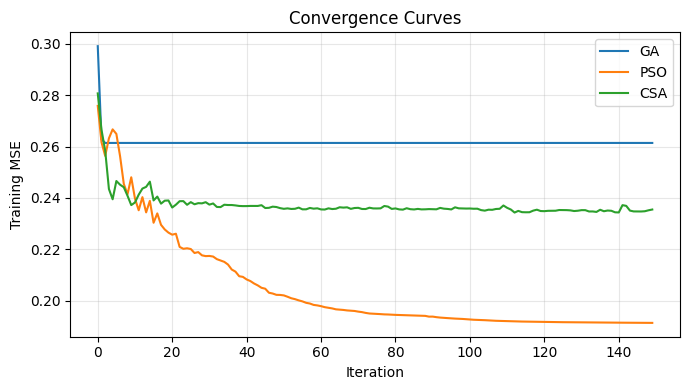

In [23]:
# ==========================================================
# 10. CONVERGENCE CURVES (MSE)
# ==========================================================
plt.figure(figsize=(7,4))
plt.plot(hist_ga, label="GA")
plt.plot(hist_pso, label="PSO")
plt.plot(hist_csa, label="CSA")
plt.xlabel("Iteration")
plt.ylabel("Training MSE")
plt.title("Convergence Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/convergence_curves.png", dpi=300)
plt.show()


In [24]:
# ==========================================================
# 12. RESULTS TABLE
# ==========================================================
metrics = ["Accuracy","Precision","Recall","F1-score"]
table = {}

for algo,(ytr,yte) in preds.items():
    table[f"{algo}-Train"] = [
        accuracy_score(y_train,ytr),
        precision_score(y_train,ytr),
        recall_score(y_train,ytr),
        f1_score(y_train,ytr)
    ]
    table[f"{algo}-Test"] = [
        accuracy_score(y_test,yte),
        precision_score(y_test,yte),
        recall_score(y_test,yte),
        f1_score(y_test,yte)
    ]

df_results = pd.DataFrame(table,index=metrics)
df_results.to_csv("results_metrics.csv")
df_results


,GA-Train,GA-Test,PSO-Train,PSO-Test,CSA-Train,CSA-Test
Accuracy,0.642140,0.605000,0.712375,0.660000,0.608696,0.630000
Precision,0.650735,0.628205,0.738462,0.706667,0.609929,0.634409
Recall,0.597973,0.494949,0.648649,0.535354,0.581081,0.595960
F1-score,0.623239,0.553672,0.690647,0.609195,0.595156,0.614583


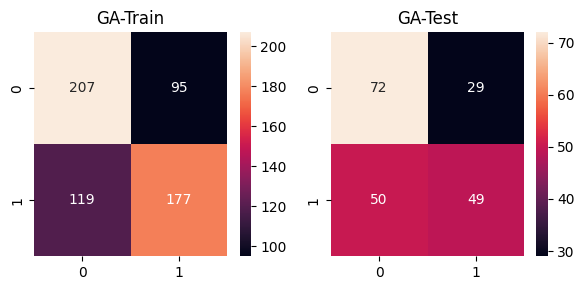

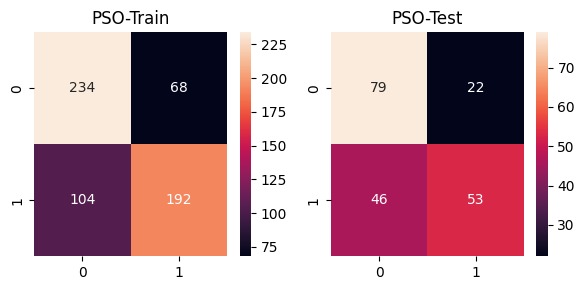

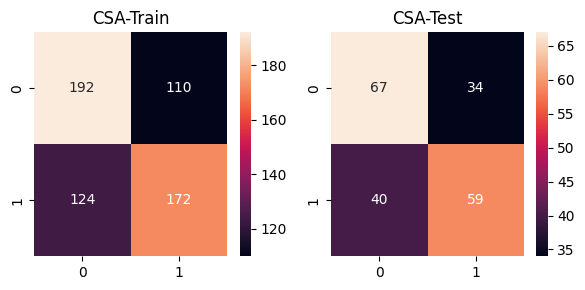

In [25]:
# ==========================================================
# 11. EVALUATION + CONFUSION MATRICES
# ==========================================================
def evaluate(best, name):
    w = decode_weights(best, X_train.shape[1], N_HIDDEN)
    ytr = (ann_forward(X_train, w).flatten() > 0.5).astype(int)
    yte = (ann_forward(X_test, w).flatten() > 0.5).astype(int)

    fig, ax = plt.subplots(1,2,figsize=(6,3))
    sns.heatmap(confusion_matrix(y_train,ytr),annot=True,fmt="d",ax=ax[0])
    sns.heatmap(confusion_matrix(y_test,yte),annot=True,fmt="d",ax=ax[1])
    ax[0].set_title(f"{name}-Train")
    ax[1].set_title(f"{name}-Test")
    plt.tight_layout()
    plt.savefig(f"figures/confusion_{name}.png", dpi=300)
    plt.show()

    return ytr, yte

preds = {
    "GA": evaluate(best_ga,"GA"),
    "PSO": evaluate(best_pso,"PSO"),
    "CSA": evaluate(best_csa,"CSA")
}

In [26]:
df_results.to_csv("results_metrics.csv")

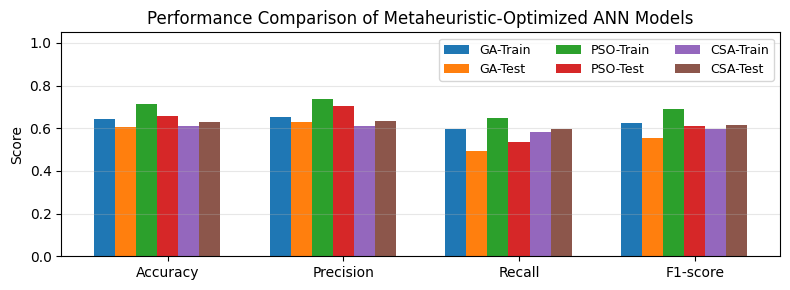

In [27]:
# ==========================================================
# 13. GROUPED BAR CHART (TRAIN vs TEST)
# ==========================================================
x = np.arange(len(metrics))
width = 0.12

plt.figure(figsize=(8,3))
for i,col in enumerate(df_results.columns):
    plt.bar(x+i*width, df_results[col], width, label=col)

plt.xticks(x+width*3, metrics)
plt.ylabel("Score")
plt.ylim(0,1.05)
plt.title("Performance Comparison of Metaheuristic-Optimized ANN Models")
plt.legend(ncol=3, fontsize=9)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("figures/performance_bar_chart.png", dpi=300)
plt.show()


In [28]:
import numpy as np
import pandas as pd
import json
from pathlib import Path

# ==========================================================
# 1. LOAD CSV + EXTRACT FEATURE NAMES
# ==========================================================
df = pd.read_csv("sleep_disordered_breathing.csv")  # <-- change this

# assume last column is target
feature_names = df.columns[:-1].tolist()

# ==========================================================
# 2. ALIGN WITH TRAINING DATA
# ==========================================================
feature_names = feature_names[:X_train.shape[1]]

# ==========================================================
# 3. MIN / MAX FROM TRAINING DATA
# ==========================================================
feature_min = X_train.min(axis=0)
feature_max = X_train.max(axis=0)

# ==========================================================
# 4. DECODE BEST PSO WEIGHTS
# ==========================================================
w1, b1, w2, b2 = decode_weights(best_pso, X_train.shape[1], N_HIDDEN)

# ==========================================================
# 5. SAVE JSON FILE
# ==========================================================
weights = {
    "w1": w1.tolist(),
    "b1": b1.tolist(),
    "w2": w2.flatten().tolist(),
    "b2": float(b2)
}

with open("pso_ann_weights.json", "w") as f:
    json.dump(weights, f)

# ==========================================================
# 6. GENERATE HTML WEB APP
# ==========================================================
html_template = f"""
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<title>Apnea Prediction</title>
<style>
body {{ font-family: Arial; margin: 30px; }}
input {{ margin: 5px; width: 180px; padding: 4px; }}
label {{ display:block; margin-top:10px; }}
button {{ margin: 15px 0; padding: 10px 15px; cursor:pointer; }}
small {{ color: gray; }}
#result {{ margin-top: 20px; font-weight: bold; font-size: 18px; }}
</style>
</head>
<body>

<h2>Apnea Prediction (PSO-ANN Model)</h2>

<form id="inputForm"></form>

<button onclick="predict()">Predict</button>

<div id="result"></div>

<script>
const weights = {json.dumps(weights)};
const featureNames = {json.dumps(feature_names)};
const featureMin = {json.dumps(feature_min.tolist())};
const featureMax = {json.dumps(feature_max.tolist())};

const nFeatures = featureNames.length;
const form = document.getElementById("inputForm");

// Create input fields dynamically
for (let i = 0; i < nFeatures; i++) {{

    let label = document.createElement("label");

    label.innerHTML = `
        <b>${{featureNames[i]}}</b>
        <small>(min: ${{featureMin[i].toFixed(2)}}, max: ${{featureMax[i].toFixed(2)}})</small>
    `;

    let input = document.createElement("input");
    input.type = "number";
    input.id = `feat${{i}}`;
    input.step = "any";
    input.min = featureMin[i];
    input.max = featureMax[i];
    input.placeholder = featureNames[i];

    form.appendChild(label);
    form.appendChild(input);
}}

// Activation functions
function sigmoid(x) {{
    return 1 / (1 + Math.exp(-x));
}}

function tanh(x) {{
    return Math.tanh(x);
}}

// Prediction function
function predict() {{
    let x = [];

    for (let i = 0; i < nFeatures; i++) {{
        let val = parseFloat(document.getElementById(`feat${{i}}`).value);

        if (isNaN(val)) {{
            alert("Please fill all features");
            return;
        }}

        x.push(val);
    }}

    let a1 = [];

    for (let j = 0; j < weights.b1.length; j++) {{
        let sum = weights.b1[j];

        for (let i = 0; i < nFeatures; i++) {{
            sum += x[i] * weights.w1[i][j];
        }}

        a1.push(tanh(sum));
    }}

    let z2 = weights.b2;

    for (let j = 0; j < weights.w2.length; j++) {{
        z2 += a1[j] * weights.w2[j];
    }}

    let y_hat = sigmoid(z2);
    let label = y_hat > 0.5 ? "Apnea" : "No Apnea";

    document.getElementById("result").innerText =
        `Prediction: ${{label}} | Probability: ${{y_hat.toFixed(3)}}`;
}}
</script>

</body>
</html>
"""

# ==========================================================
# 7. SAVE HTML FILE
# ==========================================================
Path("pso_ann_webpage.html").write_text(html_template)

print("✅ JSON saved: pso_ann_weights.json")
print("✅ HTML saved: pso_ann_webpage.html")

✅ JSON saved: pso_ann_weights.json
✅ HTML saved: pso_ann_webpage.html
